## ¿Por qué el modelo falla con nuestras grabaciones?

El modelo alcanza un accuracy del 97% y AUC 0.98 sobre el conjunto de evaluación oficial, pero clasifica incorrectamente la mayoría de nuestros audios reales.

La paradoja tiene una explicación técnica: **el modelo aprendió a reconocer "voz bonafide" tal como suena en el dataset ASVspoof 2019**, que fue grabado en condiciones controladas (audio limpio, sin ruido de fondo, micrófono profesional, formato FLAC sin compresión).

Nuestras grabaciones presentan características acústicas distintas:
- Grabadas con micrófonos de teléfono móvil
- Compresión AAC (formato m4a) con artefactos de códec
- Ruido ambiental y reverberación de sala
- Diferente respuesta en frecuencia del micrófono

A continuación comparamos visualmente las formas de onda y los espectrogramas de ambas fuentes para identificar las diferencias perceptibles.


Carga de audios (bonafide + equipo + spoof):

In [1]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import pandas as pd

# ── Parámetros ────────────────────────────────────────────────────────────────
TARGET_SR      = 16000
RUTA_PROTOCOLO = '../data/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt'
RUTA_AUDIO_DS  = '../data/LA/ASVspoof2019_LA_train/flac/'
RUTA_VOCES     = '../test_voces/'
N_EJEMPLOS     = 4

# ── Cargar protocolo ──────────────────────────────────────────────────────────
df_proto = pd.read_csv(RUTA_PROTOCOLO, sep=' ', header=None,
                       names=['speaker', 'file_name', '_', 'attack', 'label'])

archivos_bonafide = df_proto[df_proto['label'] == 'bonafide']['file_name'].tolist()
archivos_spoof    = df_proto[df_proto['label'] == 'spoof']['file_name'].tolist()

# ── Cargar audios bonafide del dataset ────────────────────────────────────────
audios_dataset, nombres_dataset = [], []
for fname in archivos_bonafide[:N_EJEMPLOS]:
    audio, _ = librosa.load(os.path.join(RUTA_AUDIO_DS, f"{fname}.flac"), sr=TARGET_SR, mono=True)
    audios_dataset.append(audio)
    nombres_dataset.append(fname[-8:])

# ── Cargar audios spoof del dataset ───────────────────────────────────────────
audios_spoof, nombres_spoof = [], []
for fname in archivos_spoof[:N_EJEMPLOS]:
    audio, _ = librosa.load(os.path.join(RUTA_AUDIO_DS, f"{fname}.flac"), sr=TARGET_SR, mono=True)
    audios_spoof.append(audio)
    nombres_spoof.append(fname[-8:])

# ── Cargar grabaciones del equipo ─────────────────────────────────────────────
archivos_equipo = sorted([f for f in os.listdir(RUTA_VOCES) if f.endswith('_16k.wav')])[:N_EJEMPLOS]
audios_equipo, nombres_equipo = [], []
for fname in archivos_equipo:
    audio, _ = librosa.load(os.path.join(RUTA_VOCES, fname), sr=TARGET_SR, mono=True)
    audios_equipo.append(audio)
    nombres_equipo.append(fname.replace('_16k.wav', ''))

print(f"Cargados: {len(audios_dataset)} bonafide dataset | {len(audios_equipo)} grabaciones equipo | {len(audios_spoof)} spoof dataset")


/Users/liliana/venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cargados: 4 bonafide dataset | 4 grabaciones equipo | 4 spoof dataset


Formas de onda en tres columnas:

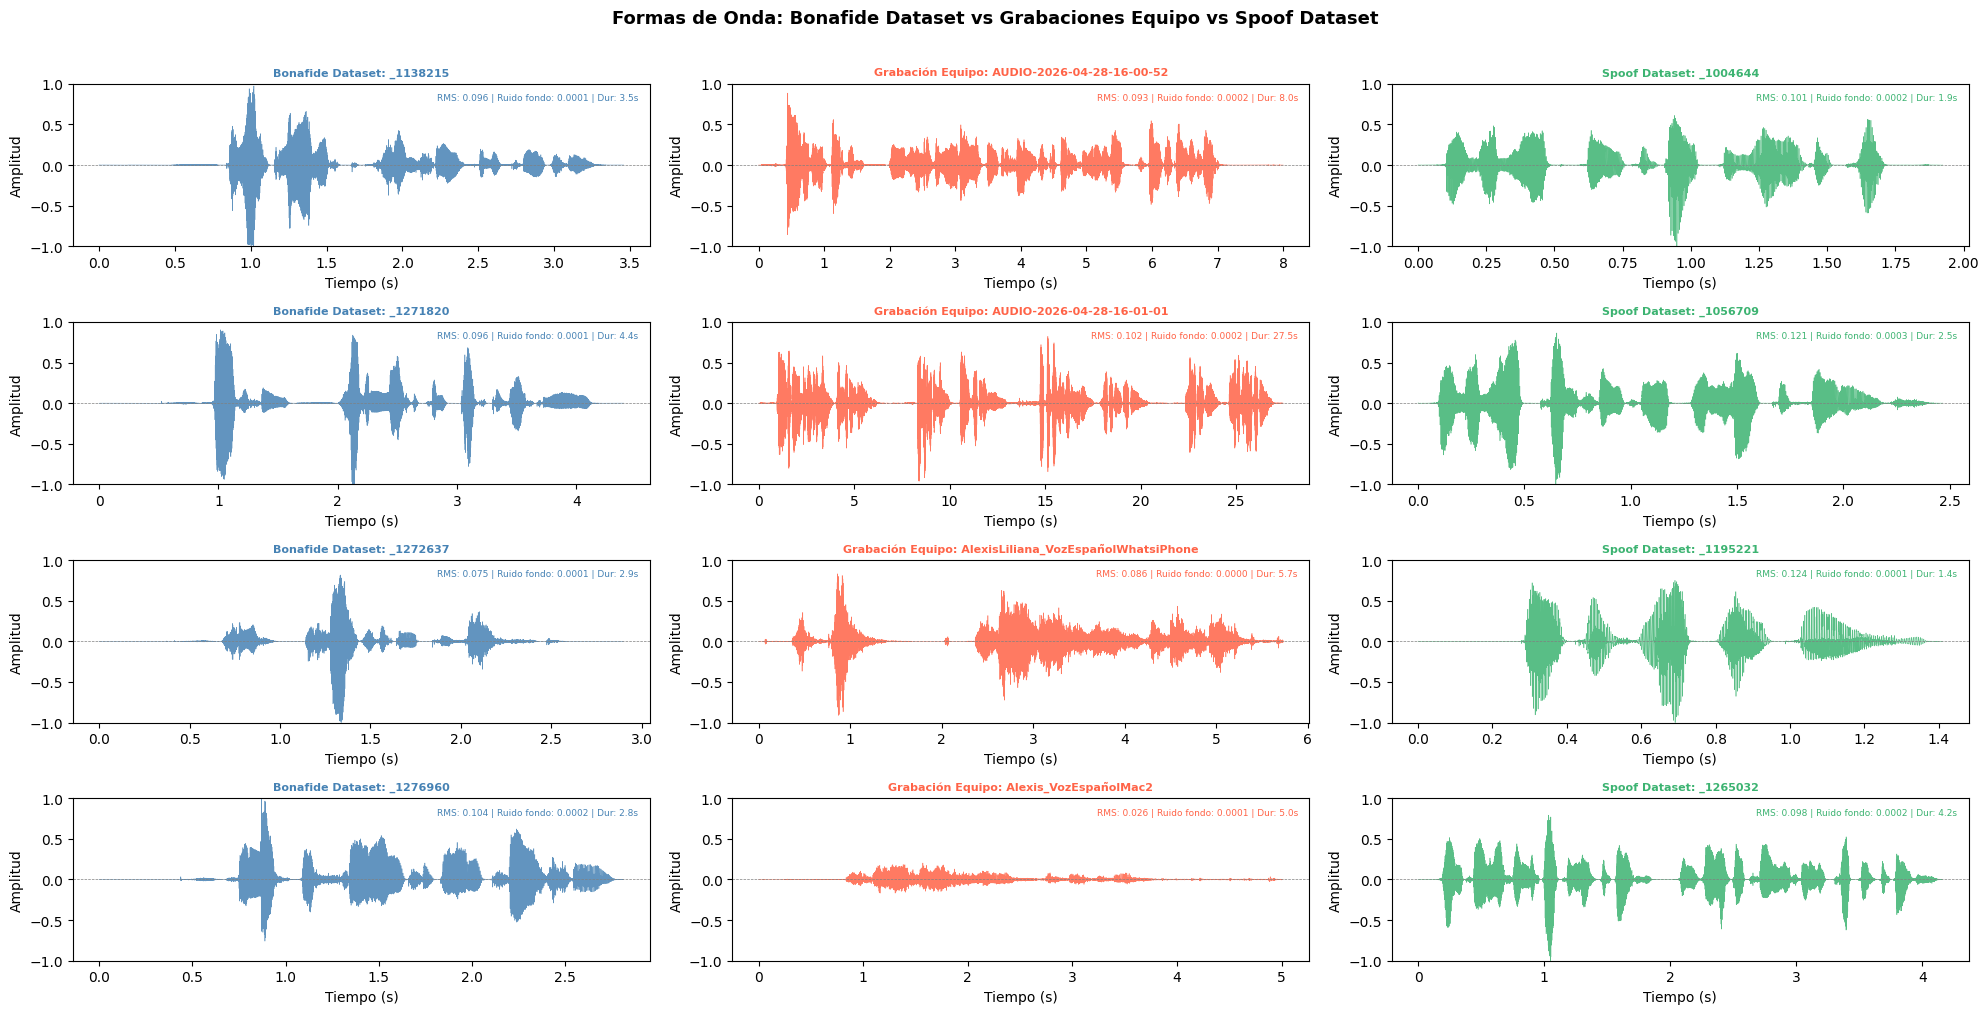

In [2]:
fig, axes = plt.subplots(N_EJEMPLOS, 3, figsize=(20, N_EJEMPLOS * 2.5))
fig.suptitle('Formas de Onda: Bonafide Dataset vs Grabaciones Equipo vs Spoof Dataset',
             fontsize=13, fontweight='bold', y=1.01)

colores  = ['steelblue', 'tomato', 'mediumseagreen']
titulos  = ['Bonafide Dataset', 'Grabación Equipo', 'Spoof Dataset']
grupos   = [audios_dataset, audios_equipo, audios_spoof]
nombres  = [nombres_dataset, nombres_equipo, nombres_spoof]

for i in range(N_EJEMPLOS):
    for j, (color, titulo, grupo, nombre_grupo) in enumerate(zip(colores, titulos, grupos, nombres)):
        ax = axes[i, j]
        audio = grupo[i]
        t = np.linspace(0, len(audio) / TARGET_SR, len(audio))
        ax.plot(t, audio, color=color, linewidth=0.4, alpha=0.85)
        ax.set_ylim(-1, 1)
        ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
        ax.set_title(f'{titulo}: {nombre_grupo[i]}', fontsize=8, fontweight='bold', color=color)
        ax.set_ylabel('Amplitud')
        ax.set_xlabel('Tiempo (s)')
        rms = np.sqrt(np.mean(audio**2))
        ruido = np.percentile(np.abs(audio), 5)
        ax.text(0.98, 0.90,
                f'RMS: {rms:.3f} | Ruido fondo: {ruido:.4f} | Dur: {len(audio)/TARGET_SR:.1f}s',
                transform=ax.transAxes, ha='right', fontsize=6.5, color=color)

plt.tight_layout()
plt.show()


Espectrogramas en tres columnas:

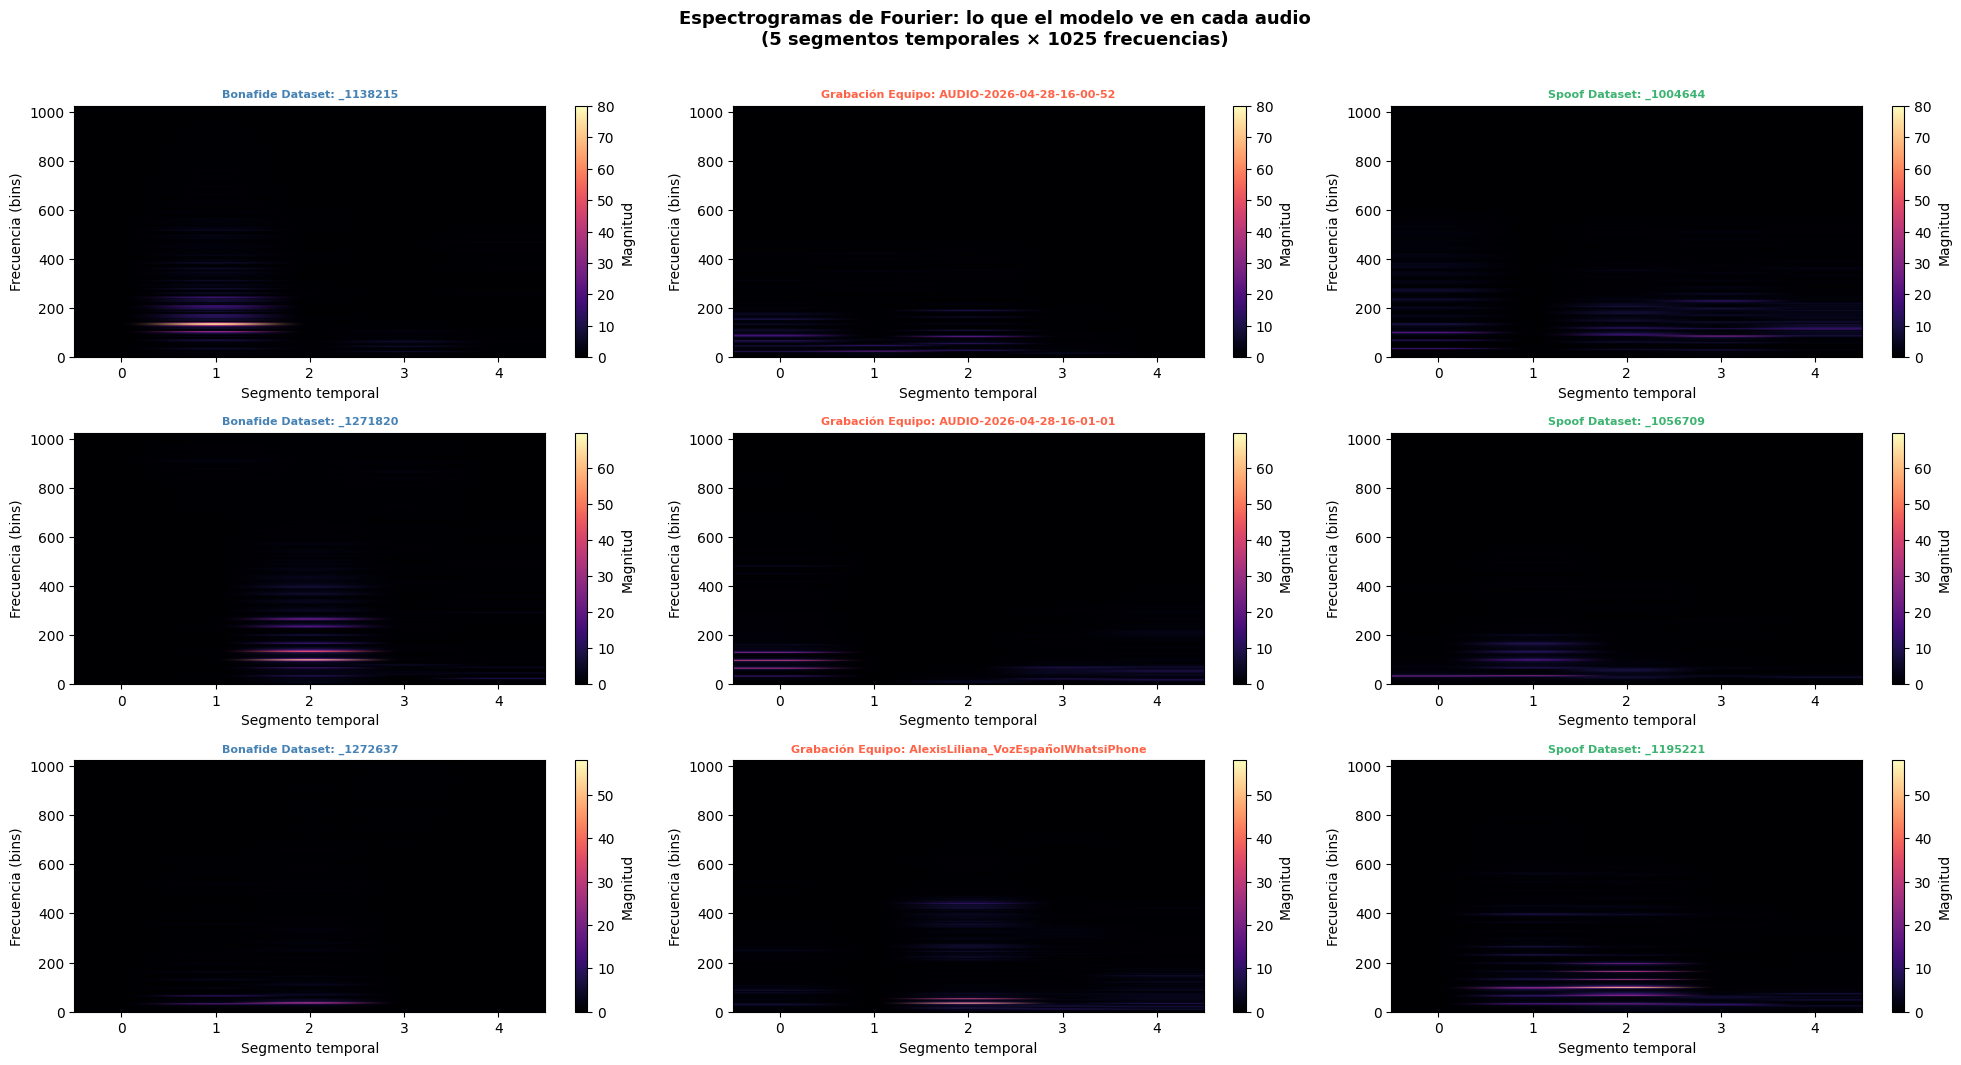

In [3]:
FRAME_LEN = 2048
N_FRAMES  = 5

def calcular_segmentos_uniformes(total_samples):
    segment_size = total_samples // N_FRAMES
    indices = []
    for i in range(N_FRAMES):
        center = (i * segment_size) + (segment_size // 2)
        start  = center - (FRAME_LEN // 2)
        end    = start + FRAME_LEN
        if start < 0:           start, end = 0, FRAME_LEN
        if end > total_samples: start, end = total_samples - FRAME_LEN, total_samples
        indices.append((start, end))
    return indices

def audio_a_espectrograma(audio):
    frames = calcular_segmentos_uniformes(len(audio))
    features = []
    for start, end in frames:
        stft = librosa.stft(audio[start:end], n_fft=FRAME_LEN, hop_length=FRAME_LEN + 1)
        features.append(np.abs(stft))
    return np.array(features).squeeze()   # (5, 1025)

N_MOSTRAR = 3
fig, axes = plt.subplots(N_MOSTRAR, 3, figsize=(20, N_MOSTRAR * 3.5))
fig.suptitle('Espectrogramas de Fourier: lo que el modelo ve en cada audio\n(5 segmentos temporales × 1025 frecuencias)',
             fontsize=13, fontweight='bold', y=1.01)

for i in range(N_MOSTRAR):
    spec_bon  = audio_a_espectrograma(audios_dataset[i])
    spec_eq   = audio_a_espectrograma(audios_equipo[i])
    spec_spo  = audio_a_espectrograma(audios_spoof[i])

    # Mismo rango de color para los tres → comparación justa
    vmax = max(spec_bon.max(), spec_eq.max(), spec_spo.max())

    for j, (spec, color, titulo, nombre_grupo) in enumerate(zip(
            [spec_bon, spec_eq, spec_spo],
            colores, titulos, nombres)):
        ax = axes[i, j]
        im = ax.imshow(spec.T, aspect='auto', origin='lower', cmap='magma',
                       vmin=0, vmax=vmax)
        ax.set_title(f'{titulo}: {nombre_grupo[i]}', fontsize=8, fontweight='bold', color=color)
        ax.set_ylabel('Frecuencia (bins)')
        ax.set_xlabel('Segmento temporal')
        plt.colorbar(im, ax=ax, label='Magnitud')

plt.tight_layout()
plt.show()


Tabla estadística comparativa:

In [4]:
def estadisticas_grupo(audios):
    return {
        'Duración media (s)':    f"{np.mean([len(a)/TARGET_SR for a in audios]):.2f}",
        'Amplitud RMS media':    f"{np.mean([np.sqrt(np.mean(a**2)) for a in audios]):.4f}",
        'Pico máximo medio':     f"{np.mean([np.max(np.abs(a)) for a in audios]):.4f}",
        'Ruido de fondo (p5)':   f"{np.mean([np.percentile(np.abs(a), 5) for a in audios]):.5f}",
    }

e_bon = estadisticas_grupo(audios_dataset)
e_eq  = estadisticas_grupo(audios_equipo)
e_spo = estadisticas_grupo(audios_spoof)

filas_extra = [
    ('Formato original',      'FLAC (sin pérdida)',     'M4A → WAV (AAC)',       'FLAC (sin pérdida)'),
    ('Entorno de grabación',  'Estudio controlado',     'Ambiente con reverb',   'Estudio controlado'),
    ('Tipo de micrófono',     'Profesional',            'Teléfono móvil',        'Profesional / TTS'),
]

print("=" * 88)
print(f"{'Característica':<28} {'Bonafide Dataset':^19} {'Grabación Equipo':^19} {'Spoof Dataset':^19}")
print("=" * 88)

for key in e_bon:
    print(f"{key:<28} {e_bon[key]:^19} {e_eq[key]:^19} {e_spo[key]:^19}")

for nombre, v_bon, v_eq, v_spo in filas_extra:
    print(f"{nombre:<28} {v_bon:^19} {v_eq:^19} {v_spo:^19}")

print("=" * 88)
print()
print("HIPÓTESIS: Si el ruido de fondo de las grabaciones del equipo es similar al del Spoof,")
print("el modelo interpreta el ruido de micrófono/códec como artefactos de síntesis de IA.")


Característica                Bonafide Dataset    Grabación Equipo      Spoof Dataset   
Duración media (s)                  3.39                11.55               2.49        
Amplitud RMS media                 0.0930              0.0768              0.1111       
Pico máximo medio                  1.0000              0.7405              1.0000       
Ruido de fondo (p5)                0.00009             0.00010             0.00021      
Formato original             FLAC (sin pérdida)    M4A → WAV (AAC)   FLAC (sin pérdida) 
Entorno de grabación         Estudio controlado  Ambiente con reverb Estudio controlado 
Tipo de micrófono                Profesional       Teléfono móvil     Profesional / TTS 

HIPÓTESIS: Si el ruido de fondo de las grabaciones del equipo es similar al del Spoof,
el modelo interpreta el ruido de micrófono/códec como artefactos de síntesis de IA.


Las caracteristicas de las grabaciones de nuestro equipo son mas parecidas al bonefide del dataset que al spoof. Sin embargo las graficas de nuestros audios son mas similares al spoof del data set que al bonafide, porque pasa esto?

Esta es una observación muy valiosa y tiene una explicación técnica precisa.

La clave está en que mides dos dominios distintos:

Lo que mides	Dominio	Resultado
RMS, pico, duración, ruido de fondo	Tiempo	Vuestras grabaciones ≈ bonafide
Espectrograma (lo que el modelo usa)	Frecuencia	Vuestras grabaciones ≈ spoof
¿Por qué ocurre esto?

Dos señales pueden tener idéntico RMS y pico en el tiempo pero verse completamente distintas en frecuencia. Las grabaciones del equipo tienen estas características en el dominio de frecuencias que las hacen parecerse al spoof:

Artefactos del códec AAC (M4A): La compresión del móvil introduce distorsiones sutiles en el espectro de frecuencias — bandas artificiales y suavizado de transientes — que son invisibles en el tiempo pero muy evidentes en el espectrograma. El audio spoof del dataset tiene exactamente el mismo tipo de patrones artificiales por ser generado por TTS/vocoders.

Respuesta en frecuencia del micrófono del móvil: Los micrófonos de teléfono no son planos — amplifican ciertas bandas (tipicamente voz ~1-3kHz) y cortan otras. Esto crea líneas horizontales en el espectrograma muy similares a los armónicos artificiales del spoof.

Reverberación de sala: Genera energía sostenida en todos los bins de frecuencia — hace el espectrograma "denso" como el spoof, en lugar del fondo negro limpio del bonafide del dataset.

En una frase: el modelo aprendió que "bonafide real" significa espectrograma con fondo negro limpio y picos orgánicos. Vuestro micrófono de móvil + compresor AAC introduce ruido estructurado en frecuencias que el modelo interpreta como firma de síntesis artificial.

Esto es en realidad un hallazgo importante para el proyecto: demuestra que el modelo no aprendió a reconocer voz humana per se, sino a reconocer las características acústicas del entorno de grabación del dataset. Es una forma de sesgo de dominio (domain mismatch) — el modelo generaliza bien dentro de los datos vistos pero no fuera de él.

## Es posible hacer un modelo que reconozca la voz humana per se y no las caracteristicas acusticas del entrono?

Sí, es posible, pero es uno de los problemas más difíciles en este campo. Hay varias aproximaciones:

1. Mejores características (features más robustas al entorno)

En lugar de magnitud STFT raw, usar:

MFCC (Mel-Frequency Cepstral Coefficients): comprimen el espectrograma de forma que reduce el efecto del canal/micrófono — es lo que usa el oído humano para percibir la voz
CQCC (Constant-Q Cepstral Coefficients): estándar actual en anti-spoofing de investigación, más robusto que STFT puro
Características prosódicas: tono, ritmo, pausas — patrones que son del hablante, no del micrófono
2. Entrenamiento con variedad de condiciones (multi-condition training)

Entrenar con grabaciones de muchos entornos distintos — móviles, micrófonos baratos, salas ruidosas, diferentes códecs — para que el modelo aprenda a ignorar el canal y fijarse solo en la voz.

3. Augmentation de dominio durante entrenamiento

Simular artificialmente:

Reverberación de sala (Room Impulse Response)
Ruido de fondo real
Compresión de códec (AAC, MP3)
Así el modelo ve durante entrenamiento exactamente el tipo de audio que luego encontrará en producción.

4. Normalización espectral (CMVN)

Cepstral Mean and Variance Normalization: resta la "huella" del canal del espectrograma antes de pasarlo al modelo, dejando solo la información del hablante.

5. Modelos pre-entrenados en audio masivo

wav2vec 2.0, HuBERT o WavLM son redes entrenadas con miles de horas de audio diverso en autosupervisado. Aprenden representaciones fonéticas casi independientes del entorno. Usarlos como base (fine-tuning) daría generalización muy superior a entrenar desde cero.

La realidad del campo:

Incluso los mejores sistemas del mundo en las competiciones ASVspoof siguen fallando cuando se prueban fuera del dominio de entrenamiento. El domain mismatch es un problema abierto. El vuestro no es un error de diseño — es el mismo problema que enfrenta la investigación actual.

Para vuestro proyecto, esto es una conclusión muy sólida: habéis identificado y explicado exactamente por qué un modelo con 97% de accuracy falla en condiciones reales, y eso demuestra comprensión profunda del problema.

